# 04 — Gradients and gradient descent: local sensitivity becomes movement

A gradient answers: **if this parameter changes slightly, how does loss change?**

## What you should learn
- derivative as local slope;
- finite difference vs analytic derivative;
- gradient vector for multiple parameters;
- why gradient descent moves *against* the gradient;
- why learning rate controls step size rather than direction.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(precision=5, suppress=True)
RNG = np.random.default_rng(42)


## 1. Finite differences: estimate a derivative without symbolic calculus


In [2]:
f=lambda w:(2*w+1-5)**2
w=0.5
analytic=2*(2*w+1-5)*2
rows=[]
for eps in [1,0.1,0.01,0.001,1e-4]:
    approx=(f(w+eps)-f(w-eps))/(2*eps)
    rows.append([eps,approx,analytic,abs(approx-analytic)])
pd.DataFrame(rows,columns=['epsilon','finite difference','analytic derivative','absolute error'])


,epsilon,finite difference,analytic derivative,absolute error
0,1.0000,-12.0,-12.0,0.000000e+00
1,0.1000,-12.0,-12.0,1.421085e-14
2,0.0100,-12.0,-12.0,1.065814e-14
3,0.0010,-12.0,-12.0,1.321609e-12
4,0.0001,-12.0,-12.0,1.321609e-12


## 2. A real logistic neuron gradient
For sigmoid + BCE, a useful simplification is

$$\frac{\partial \mathcal L}{\partial z}=\hat y-y$$

and because $z=w^Tx+b$:

$$\frac{\partial \mathcal L}{\partial w}=x(\hat y-y),\qquad
\frac{\partial \mathcal L}{\partial b}=\hat y-y$$


In [3]:
x=np.array([1.2,-.7]);w=np.array([.4,-.2]);b=.1;y=1.0
z=w@x+b;p=1/(1+np.exp(-z));dz=p-y;dw=x*dz;db=dz
print(f'z={z:.5f}, p={p:.5f}, dL/dz={dz:.5f}')
print('dL/dw=',dw,'dL/db=',db)


z=0.72000, p=0.67261, dL/dz=-0.32739
dL/dw= [-0.39287  0.22918] dL/db= -0.3273929829322396


In [4]:
# numeric gradient check
loss=lambda ww,bb:-(y*np.log(1/(1+np.exp(-(ww@x+bb)))+1e-12)+(1-y)*np.log(1-1/(1+np.exp(-(ww@x+bb)))+1e-12))
eps=1e-6
num=[]
for j in range(2):
    wp=w.copy();wm=w.copy();wp[j]+=eps;wm[j]-=eps
    num.append((loss(wp,b)-loss(wm,b))/(2*eps))
num_db=(loss(w,b+eps)-loss(w,b-eps))/(2*eps)
print('analytic dw:',dw,'numeric dw:',num)
print('analytic db:',db,'numeric db:',num_db)


analytic dw: [-0.39287  0.22918] numeric dw: [np.float64(-0.39287157949097207), np.float64(0.22917508799014108)]
analytic db: -0.3273929829322396 numeric db: -0.3273929828628841


## 3. Learning-rate trajectories
Same gradient direction, different step sizes.


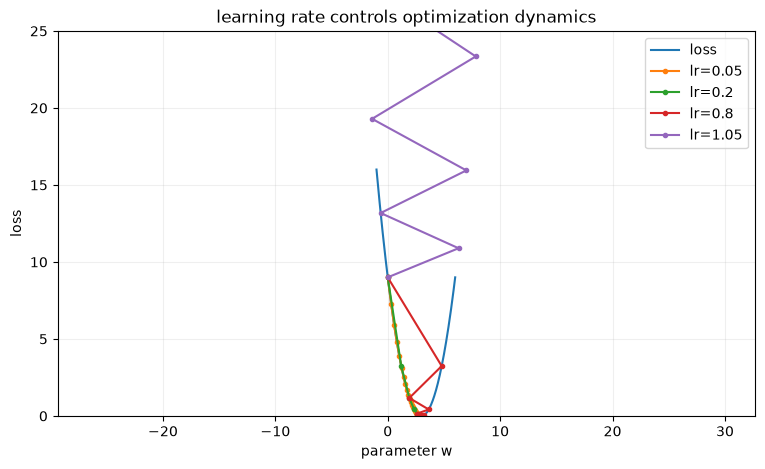

In [5]:
def gd(lr,steps=25):
    ww=0.0;path=[]
    for _ in range(steps):
        grad=2*(ww-3)
        path.append((ww,(ww-3)**2))
        ww-=lr*grad
    return np.array(path)
xx=np.linspace(-1,6,400);plt.figure(figsize=(9,5));plt.plot(xx,(xx-3)**2,label='loss')
for lr in [.05,.2,.8,1.05]:
    pth=gd(lr);plt.plot(pth[:,0],pth[:,1],marker='o',ms=3,label=f'lr={lr}')
plt.ylim(0,25);plt.xlabel('parameter w');plt.ylabel('loss');plt.title('learning rate controls optimization dynamics');plt.legend();plt.grid(alpha=.2);plt.show()


### Inference / insight
- gradient sign determines the local uphill direction;
- descent negates that direction;
- learning rate scales the step;
- too small → slow; too large → overshoot/instability.

Backpropagation is simply the scalable mechanism used to compute these gradients through many chained operations.
